<a href="https://colab.research.google.com/github/kledihaxhimali/Data-Science-Projects/blob/Stock-Prices/StockPrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA COLLECTION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/BAJAJFINSV.csv')
df.head(3)

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2008-05-26,BAJAJFINSV,EQ,2101.05,600.0,619.00,501.0,505.1,509.10,548.85,3145446,1.726368e+14,NaN,908264,0.2888
1,2008-05-27,BAJAJFINSV,EQ,509.10,505.0,610.95,491.1,564.0,554.65,572.15,4349144,2.488370e+14,NaN,677627,0.1558
2,2008-05-28,BAJAJFINSV,EQ,554.65,564.0,665.60,564.0,643.0,640.95,618.37,4588759,2.837530e+14,NaN,774895,0.1689


In [ ]:
data= df.set_index('Date')
data.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2008-05-26,BAJAJFINSV,EQ,2101.05,600.00,619.00,501.0,505.1,509.10,548.85,3145446,1.726368e+14,NaN,908264,0.2888
2008-05-27,BAJAJFINSV,EQ,509.10,505.00,610.95,491.1,564.0,554.65,572.15,4349144,2.488370e+14,NaN,677627,0.1558
2008-05-28,BAJAJFINSV,EQ,554.65,564.00,665.60,564.0,643.0,640.95,618.37,4588759,2.837530e+14,NaN,774895,0.1689
2008-05-29,BAJAJFINSV,EQ,640.95,656.65,703.00,608.0,634.5,632.40,659.60,4522302,2.982921e+14,NaN,1006161,0.2225
2008-05-30,BAJAJFINSV,EQ,632.40,642.40,668.00,588.3,647.0,644.00,636.41,3057669,1.945929e+14,NaN,462832,0.1514


In [ ]:
data.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,3201.000000,3201.000000,3201.000000,3201.000000,3201.000000,3201.000000,3201.000000,3.201000e+03,3.201000e+03,2456.000000,3.201000e+03,3201.000000
mean,2755.864386,2760.382381,2803.614449,2716.731443,2758.781537,2758.657451,2761.156954,2.315312e+05,9.533424e+13,20892.811075,7.409510e+04,0.471614
std,2869.811765,2874.814173,2912.885262,2834.037357,2873.792614,2873.522615,2874.033545,4.402681e+05,2.176448e+14,32396.302068,1.464012e+05,0.218910
min,90.750000,88.150000,93.100000,88.150000,91.000000,90.750000,89.260000,4.570000e+02,1.376712e+10,149.000000,4.560000e+02,0.056200
25%,527.900000,528.600000,542.600000,520.000000,527.950000,527.900000,531.270000,3.981100e+04,2.751053e+12,2951.750000,2.086300e+04,0.287400
50%,1098.700000,1095.000000,1118.000000,1080.250000,1100.000000,1098.700000,1103.560000,9.995300e+04,1.090486e+13,9450.000000,4.159700e+04,0.469700
75%,5121.900000,5120.000000,5199.800000,5042.800000,5115.000000,5125.100000,5127.510000,2.315400e+05,8.755946e+13,24439.750000,8.308900e+04,0.636000
max,11176.550000,11000.000000,11300.000000,10868.700000,11175.450000,11176.550000,11081.780000,6.271671e+06,3.394379e+15,312959.000000,3.804696e+06,1.000000


# DATA CLEANING

In [ ]:
data.isna().sum()

,0
Symbol,0
Series,0
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0
Volume,0


In [ ]:
data[data['Trades'].isna()]

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2008-05-26,BAJAJFINSV,EQ,2101.05,600.00,619.00,501.00,505.10,509.10,548.85,3145446,1.726368e+14,NaN,908264,0.2888
2008-05-27,BAJAJFINSV,EQ,509.10,505.00,610.95,491.10,564.00,554.65,572.15,4349144,2.488370e+14,NaN,677627,0.1558
2008-05-28,BAJAJFINSV,EQ,554.65,564.00,665.60,564.00,643.00,640.95,618.37,4588759,2.837530e+14,NaN,774895,0.1689
2008-05-29,BAJAJFINSV,EQ,640.95,656.65,703.00,608.00,634.50,632.40,659.60,4522302,2.982921e+14,NaN,1006161,0.2225
2008-05-30,BAJAJFINSV,EQ,632.40,642.40,668.00,588.30,647.00,644.00,636.41,3057669,1.945929e+14,NaN,462832,0.1514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-05-25,BAJAJFINSV,EQ,490.50,485.00,498.50,485.00,489.00,485.95,491.58,68329,3.358895e+12,NaN,17938,0.2625
2011-05-26,BAJAJFINSV,EQ,485.95,489.90,491.40,482.20,485.40,484.70,486.95,27605,1.344235e+12,NaN,8579,0.3108
2011-05-27,BAJAJFINSV,EQ,484.70,485.65,492.00,484.05,486.30,486.90,487.88,35212,1.717919e+12,NaN,11239,0.3192


In [ ]:
dataframe=data.drop(columns=['Trades'], axis=1)
dataframe.columns

Index(['Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

In [ ]:
data[dataframe.duplicated()]

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,


In [ ]:
dataframe.dtypes

,0
Symbol,object
Series,object
Prev Close,float64
Open,float64
High,float64
Low,float64
Last,float64
Close,float64
VWAP,float64
Volume,int64


# DATA ANALYSIS

<Axes: xlabel='Date'>

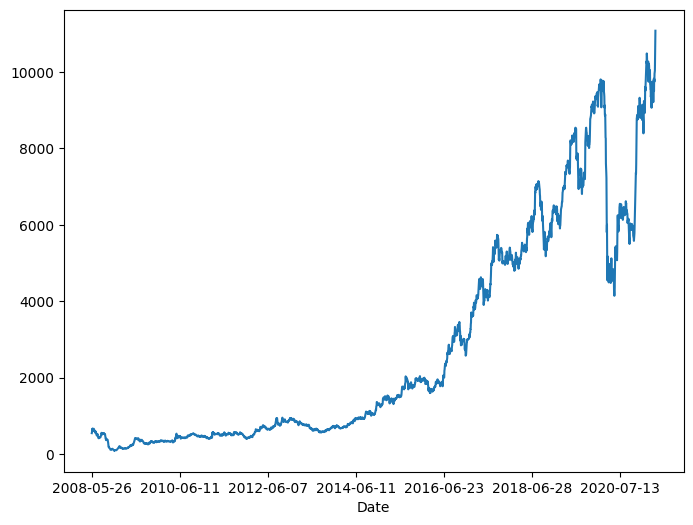

In [ ]:
data['VWAP'].plot(figsize=(8, 6))

<Axes: xlabel='VWAP', ylabel='Count'>

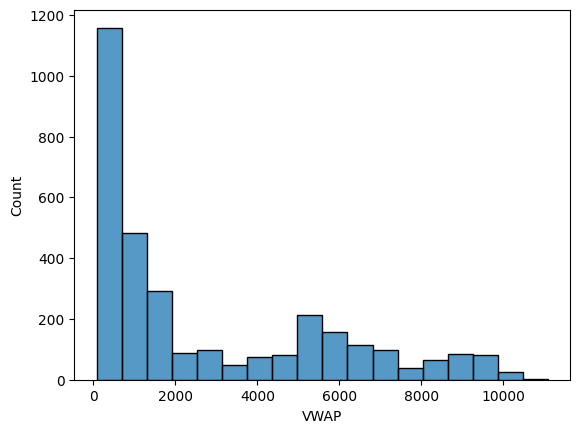

In [ ]:
sns.histplot(data= dataframe, x='VWAP')

<Axes: xlabel='VWAP', ylabel='Density'>

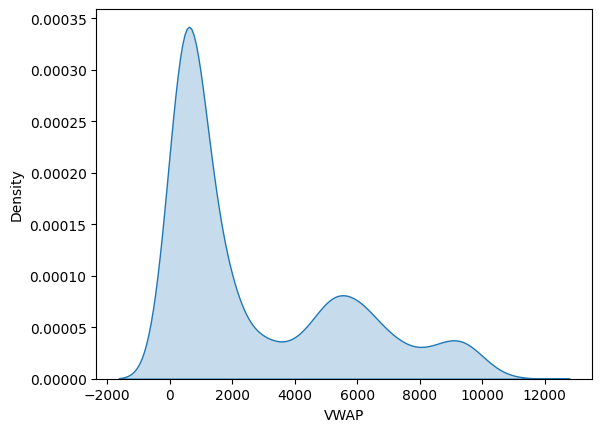

In [ ]:
sns.kdeplot(data= dataframe, x='VWAP', fill='True')


((array([-3.51908695, -3.27647555, -3.14237236, ...,  3.14237236,
          3.27647555,  3.51908695]),
  array([   89.26,    93.99,    94.79, ..., 10486.75, 10980.4 , 11081.78])),
 (2583.530410402808, 2761.156954076851, 0.8981685068494002))

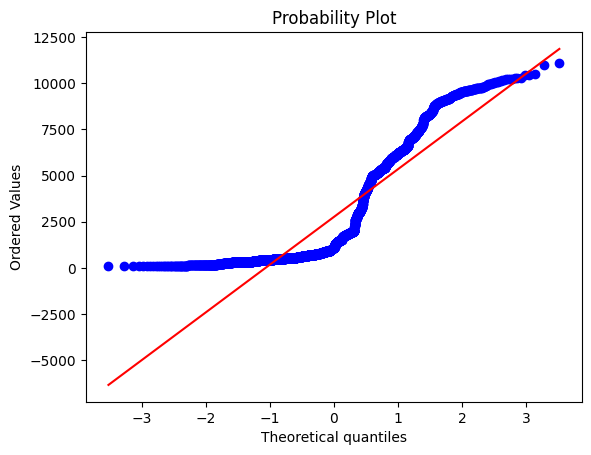

In [ ]:
from scipy import stats
stats.probplot(x=dataframe['VWAP'], plot=plt)


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

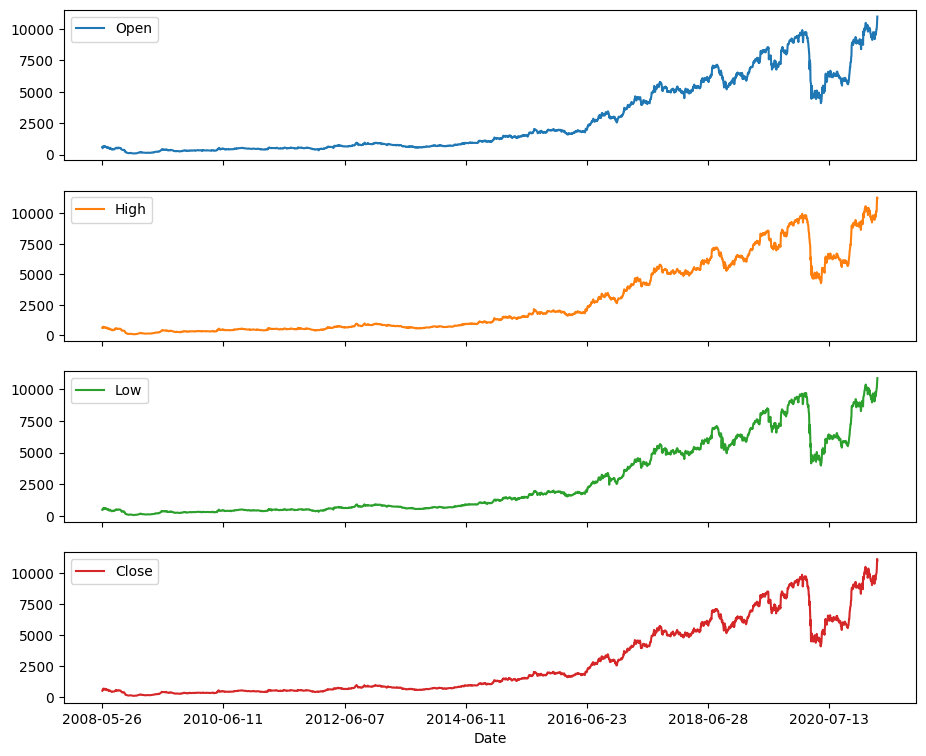

In [ ]:
cols = ['Open', 'High','Low','Close']
dataframe[cols].plot(figsize=(11, 9), subplots=True)

In [ ]:
!pip install plotly
import plotly.graph_objects as go
fig =go.Figure(data=[go.Candlestick(x=dataframe.index[0:50],
                open=dataframe['Open'][0:50],
                high=dataframe['High'][0:50],
                low=dataframe['Low'][0:50],
                close=dataframe['Close'][0:50])])


In [ ]:
fig.update_layout(xaxis_rangeslider_visible=False)

# FEATURE ENGINEERING

In [ ]:
dataframe["Close"][0:10]

,Close
Date,
2008-05-26,509.10
2008-05-27,554.65
2008-05-28,640.95
2008-05-29,632.40
2008-05-30,644.00
2008-06-02,686.95
2008-06-03,672.05
2008-06-04,598.95
2008-06-05,631.85


In [ ]:
lag_features = ["High", "Low", "Volume", "Turnover"]
window1=3
window2=7
data['High'].rolling(window= 3).mean()

,High
Date,
2008-05-26,NaN
2008-05-27,NaN
2008-05-28,631.850000
2008-05-29,659.850000
2008-05-30,678.866667
...,...
2021-04-26,10059.766667
2021-04-27,10133.466667
2021-04-28,10291.316667


In [ ]:
for col in lag_features:
  dataframe[col+ '_rolling_mean_3']=dataframe[col].rolling(window= window1).mean()
  dataframe[col+ '_rolling_mean_7']=dataframe[col].rolling(window= window2).mean()
dataframe.columns

Index(['Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Deliverable Volume',
       '%Deliverble', 'High_rolling_mean_3', 'High_rolling_mean_7',
       'Low_rolling_mean_3', 'Low_rolling_mean_7', 'Volume_rolling_mean_3',
       'Volume_rolling_mean_7', 'Turnover_rolling_mean_3',
       'Turnover_rolling_mean_7'],
      dtype='object')

In [ ]:
for col in lag_features:
  dataframe[col+ '_rolling_std_3']=dataframe[col].rolling(window= window1).std()
  dataframe[col+ '_rolling_std_7']=dataframe[col].rolling(window= window2).std()
dataframe.head(3)

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,Turnover_rolling_mean_3,Turnover_rolling_mean_7,High_rolling_std_3,High_rolling_std_7,Low_rolling_std_3,Low_rolling_std_7,Volume_rolling_std_3,Volume_rolling_std_7,Turnover_rolling_std_3,Turnover_rolling_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2008-05-26,BAJAJFINSV,EQ,2101.05,600.0,619.00,501.0,505.1,509.10,548.85,3145446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-05-27,BAJAJFINSV,EQ,509.10,505.0,610.95,491.1,564.0,554.65,572.15,4349144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-05-28,BAJAJFINSV,EQ,554.65,564.0,665.60,564.0,643.0,640.95,618.37,4588759,...,2.350756e+14,NaN,29.504195,NaN,39.542003,NaN,773461.552524,NaN,5.682195e+13,NaN


# MODEL BUILDING

In [ ]:
dataframe.dropna(inplace=True)
dataframe.isna().sum()
training_data=dataframe[0:2400]
testing_data=dataframe[2400:]


In [ ]:

import pmdarima

In [ ]:
dataframe.columns

Index(['Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Deliverable Volume',
       '%Deliverble', 'High_rolling_mean_3', 'High_rolling_mean_7',
       'Low_rolling_mean_3', 'Low_rolling_mean_7', 'Volume_rolling_mean_3',
       'Volume_rolling_mean_7', 'Turnover_rolling_mean_3',
       'Turnover_rolling_mean_7', 'High_rolling_std_3', 'High_rolling_std_7',
       'Low_rolling_std_3', 'Low_rolling_std_7', 'Volume_rolling_std_3',
       'Volume_rolling_std_7', 'Turnover_rolling_std_3',
       'Turnover_rolling_std_7'],
      dtype='object')

In [ ]:
ind_features=['High_rolling_mean_3', 'High_rolling_mean_7',
       'Low_rolling_mean_3', 'Low_rolling_mean_7', 'Volume_rolling_mean_3',
       'Volume_rolling_mean_7', 'Turnover_rolling_mean_3',
       'Turnover_rolling_mean_7', 'High_rolling_std_3', 'High_rolling_std_7',
       'Low_rolling_std_3', 'Low_rolling_std_7', 'Volume_rolling_std_3',
       'Volume_rolling_std_7', 'Turnover_rolling_std_3',
       'Turnover_rolling_std_7']

In [ ]:
from pmdarima import auto_arima
model =auto_arima(y= training_data['VWAP'], X=training_data[ind_features], trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=21501.827, Time=19.21 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=22553.316, Time=8.27 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=21962.078, Time=4.57 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=21621.883, Time=10.58 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=38832.057, Time=3.65 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=21603.202, Time=11.24 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=21569.178, Time=10.29 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=21504.409, Time=11.23 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=21496.739, Time=12.09 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=21507.705, Time=10.60 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=21498.526, Time=11.74 sec
 ARIMA(2,0,4)(0,0,0)[0] intercept   : AIC=21493.512, Time=16.52 sec
 ARIMA(1,0,4)(0,0,0)[0] intercept   : AIC=21504.632, Time=12.47 sec
 ARIMA(3,0,4)(0,0,0)[0] intercept   : AIC=21484.767, Time=13.47 sec
 ARIMA(4

In [ ]:
model

ARIMA(order=(3, 0, 4), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [ ]:
forecast=model.predict(n_periods= len(testing_data), X= testing_data[ind_features])
forecast

,0
2400,5062.232272
2401,5067.142982
2402,5140.062416
2403,5181.648066
2404,5206.023326
...,...
3190,9986.660883
3191,10045.074683
3192,10286.940502
3193,10784.834286


In [ ]:
testing_data

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,Turnover_rolling_mean_3,Turnover_rolling_mean_7,High_rolling_std_3,High_rolling_std_7,Low_rolling_std_3,Low_rolling_std_7,Volume_rolling_std_3,Volume_rolling_std_7,Turnover_rolling_std_3,Turnover_rolling_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2018-02-09,BAJAJFINSV,EQ,5057.25,4989.90,5088.00,4961.20,5068.00,5059.35,5037.19,144600,...,8.401559e+13,1.265139e+14,61.024585,79.389987,24.407188,167.521603,30344.593758,91750.413573,1.452758e+13,4.514870e+13
2018-02-12,BAJAJFINSV,EQ,5059.35,5096.30,5244.00,5042.80,5210.00,5235.45,5184.22,141176,...,7.493284e+13,1.122500e+14,78.136632,103.400785,43.676538,183.106338,6967.448983,89474.878072,3.329531e+12,4.375212e+13
2018-02-14,BAJAJFINSV,EQ,5235.45,5260.00,5350.00,5152.30,5175.00,5189.00,5272.21,154547,...,7.583563e+13,9.691195e+13,131.792767,142.107292,95.888842,213.253902,6945.624834,62661.570046,4.891723e+12,2.863090e+13
2018-02-15,BAJAJFINSV,EQ,5189.00,5200.00,5291.00,5112.05,5134.00,5130.35,5197.04,104197,...,6.960694e+13,8.393934e+13,53.113087,141.943483,55.386333,215.827622,26081.131692,51372.889474,1.401207e+13,2.331018e+13
2018-02-16,BAJAJFINSV,EQ,5130.35,5168.85,5199.80,5030.00,5055.55,5058.25,5089.32,88468,...,6.021876e+13,7.227025e+13,75.673069,105.413408,62.329173,81.747523,34518.010231,36848.735971,1.897032e+13,1.822208e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-26,BAJAJFINSV,EQ,9916.65,9992.00,10125.00,9902.20,10000.85,10001.75,9995.72,419596,...,5.373954e+14,5.745917e+14,128.351484,169.093838,146.395401,162.086761,109533.081199,142403.920078,1.061869e+14,1.363635e+14
2021-04-27,BAJAJFINSV,EQ,10001.75,10000.00,10133.00,9964.70,10133.00,10091.35,10036.76,342847,...,4.629427e+14,5.423889e+14,8.709382,179.000539,115.977857,195.182734,147568.937973,169831.588726,1.455642e+14,1.619714e+14
2021-04-28,BAJAJFINSV,EQ,10091.35,10200.00,10615.95,10151.15,10480.00,10489.30,10445.96,1113881,...,6.423597e+14,6.524561e+14,281.169168,295.422139,129.515736,257.671610,424738.252610,255574.915252,4.529369e+14,2.696174e+14


<Axes: xlabel='Date'>

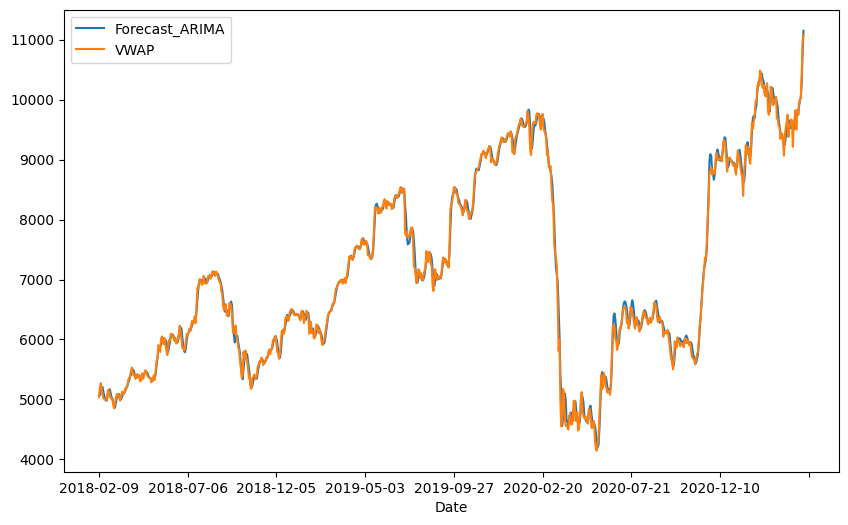

In [ ]:
testing_data['Forecast_ARIMA']= forecast.values
testing_data[['Forecast_ARIMA', 'VWAP']].plot(figsize=(10, 6))

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print(mean_squared_error(testing_data['VWAP'], testing_data['Forecast_ARIMA']))
print(np.sqrt(mean_squared_error(testing_data['VWAP'], testing_data['Forecast_ARIMA'])))
print(mean_absolute_error(testing_data['VWAP'], testing_data['Forecast_ARIMA']))

11857.648902780127
108.89283219193138
76.36075997041975
